In [3]:
import pandas as pd

df = pd.read_csv("data/upi_transactions.csv")
df.head()

,transaction id,transaction_date,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank
0,TXN0000000001,08-10-2024 15:17,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis
1,TXN0000000002,11-04-2024 06:56,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI
2,TXN0000000003,02-04-2024 13:27,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank
3,TXN0000000004,07-01-2024 10:09,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI
4,TXN0000000005,23-01-2024 19:04,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis


In [4]:
df.shape

(250000, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   transaction_date    250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
dtypes: int64(1), object(9)
memory usage: 19.1+ MB


In [6]:
df["transaction_date"] = pd.to_datetime(

    df["transaction_date"],
    format = "%d-%m-%Y %H:%M"
)

In [7]:
#feature engineering 

df["Year"] = df["transaction_date"].dt.year
df["Month"] = df["transaction_date"].dt.month
df["Day"] = df["transaction_date"].dt.day
df["Hour"] = df["transaction_date"].dt.hour
df["Minute"] = df["transaction_date"].dt.minute
df["Weekday"] = df["transaction_date"].dt.day_name()
df["Quater"] = df["transaction_date"].dt.quarter

df.head()

,transaction id,transaction_date,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,Year,Month,Day,Hour,Minute,Weekday,Quater
0,TXN0000000001,2024-10-08 15:17:00,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,2024,10,8,15,17,Tuesday,4
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,2024,4,11,6,56,Thursday,2
2,TXN0000000003,2024-04-02 13:27:00,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,2024,4,2,13,27,Tuesday,2
3,TXN0000000004,2024-01-07 10:09:00,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,2024,1,7,10,9,Sunday,1
4,TXN0000000005,2024-01-23 19:04:00,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,2024,1,23,19,4,Tuesday,1


In [8]:
df.iloc[0]

transaction id              TXN0000000001
transaction_date      2024-10-08 15:17:00
transaction type                      P2P
merchant_category           Entertainment
amount (INR)                          868
transaction_status                SUCCESS
sender_age_group                    26-35
receiver_age_group                  18-25
sender_state                        Delhi
sender_bank                          Axis
Year                                 2024
Month                                  10
Day                                     8
Hour                                   15
Minute                                 17
Weekday                           Tuesday
Quater                                  4
Name: 0, dtype: object

In [9]:
df.iloc[0:5]

,transaction id,transaction_date,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,Year,Month,Day,Hour,Minute,Weekday,Quater
0,TXN0000000001,2024-10-08 15:17:00,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,2024,10,8,15,17,Tuesday,4
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,2024,4,11,6,56,Thursday,2
2,TXN0000000003,2024-04-02 13:27:00,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,2024,4,2,13,27,Tuesday,2
3,TXN0000000004,2024-01-07 10:09:00,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,2024,1,7,10,9,Sunday,1
4,TXN0000000005,2024-01-23 19:04:00,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,2024,1,23,19,4,Tuesday,1


In [10]:
df = df.set_index("transaction_date")
df.head()

,transaction id,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,Year,Month,Day,Hour,Minute,Weekday,Quater
transaction_date,,,,,,,,,,,,,,,,
2024-10-08 15:17:00,TXN0000000001,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,2024,10,8,15,17,Tuesday,4
2024-04-11 06:56:00,TXN0000000002,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,2024,4,11,6,56,Thursday,2
2024-04-02 13:27:00,TXN0000000003,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,2024,4,2,13,27,Tuesday,2
2024-01-07 10:09:00,TXN0000000004,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,2024,1,7,10,9,Sunday,1
2024-01-23 19:04:00,TXN0000000005,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,2024,1,23,19,4,Tuesday,1


In [11]:
df.loc["2024-10-08"]

,transaction id,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,Year,Month,Day,Hour,Minute,Weekday,Quater
transaction_date,,,,,,,,,,,,,,,,
2024-10-08 15:17:00,TXN0000000001,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,2024,10,8,15,17,Tuesday,4
2024-10-08 18:12:00,TXN0000000485,P2M,Shopping,308,SUCCESS,26-35,18-25,Delhi,Yes Bank,2024,10,8,18,12,Tuesday,4
2024-10-08 16:55:00,TXN0000001116,P2M,Food,162,SUCCESS,18-25,26-35,Karnataka,ICICI,2024,10,8,16,55,Tuesday,4
2024-10-08 23:54:00,TXN0000001501,P2P,Education,17641,SUCCESS,46-55,18-25,Andhra Pradesh,Axis,2024,10,8,23,54,Tuesday,4
2024-10-08 12:11:00,TXN0000001554,Bill Payment,Grocery,276,SUCCESS,26-35,26-35,Tamil Nadu,HDFC,2024,10,8,12,11,Tuesday,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-08 23:26:00,TXN0000247470,P2P,Food,67,SUCCESS,36-45,36-45,Tamil Nadu,SBI,2024,10,8,23,26,Tuesday,4
2024-10-08 11:03:00,TXN0000247578,P2M,Fuel,573,SUCCESS,26-35,36-45,Telangana,PNB,2024,10,8,11,3,Tuesday,4
2024-10-08 17:07:00,TXN0000248029,P2P,Shopping,1714,SUCCESS,26-35,26-35,Rajasthan,PNB,2024,10,8,17,7,Tuesday,4


In [12]:
df = df.sort_index()

In [13]:
df.head()

,transaction id,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,Year,Month,Day,Hour,Minute,Weekday,Quater
transaction_date,,,,,,,,,,,,,,,,
2024-01-01 00:05:00,TXN0000173177,P2M,Grocery,1540,SUCCESS,18-25,36-45,Delhi,Axis,2024,1,1,0,5,Monday,1
2024-01-01 00:09:00,TXN0000149806,P2P,Utilities,1438,SUCCESS,26-35,46-55,Uttar Pradesh,Axis,2024,1,1,0,9,Monday,1
2024-01-01 00:23:00,TXN0000100282,P2M,Utilities,394,SUCCESS,36-45,18-25,Telangana,Yes Bank,2024,1,1,0,23,Monday,1
2024-01-01 00:25:00,TXN0000184313,P2P,Shopping,1716,SUCCESS,26-35,46-55,Maharashtra,SBI,2024,1,1,0,25,Monday,1
2024-01-01 00:29:00,TXN0000218473,P2P,Shopping,439,SUCCESS,26-35,18-25,West Bengal,Axis,2024,1,1,0,29,Monday,1


In [14]:
df.loc["2024-08-01":"2024-08-31"]

,transaction id,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,Year,Month,Day,Hour,Minute,Weekday,Quater
transaction_date,,,,,,,,,,,,,,,,
2024-08-01 00:15:00,TXN0000040324,Bill Payment,Shopping,2377,SUCCESS,18-25,36-45,Karnataka,SBI,2024,8,1,0,15,Thursday,3
2024-08-01 00:18:00,TXN0000163114,P2P,Other,403,SUCCESS,36-45,18-25,Uttar Pradesh,Yes Bank,2024,8,1,0,18,Thursday,3
2024-08-01 00:21:00,TXN0000149890,P2P,Grocery,1010,SUCCESS,36-45,26-35,Telangana,HDFC,2024,8,1,0,21,Thursday,3
2024-08-01 00:21:00,TXN0000002567,P2P,Grocery,2413,SUCCESS,36-45,26-35,Andhra Pradesh,SBI,2024,8,1,0,21,Thursday,3
2024-08-01 00:29:00,TXN0000141355,Bill Payment,Utilities,4334,SUCCESS,26-35,26-35,Tamil Nadu,HDFC,2024,8,1,0,29,Thursday,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31 23:38:00,TXN0000056066,Bill Payment,Grocery,2017,SUCCESS,56+,26-35,Gujarat,SBI,2024,8,31,23,38,Saturday,3
2024-08-31 23:41:00,TXN0000112603,P2P,Grocery,900,SUCCESS,46-55,26-35,Delhi,SBI,2024,8,31,23,41,Saturday,3
2024-08-31 23:50:00,TXN0000196226,P2P,Food,300,SUCCESS,36-45,26-35,Karnataka,ICICI,2024,8,31,23,50,Saturday,3


In [15]:
#Date Arithmetic - find the difference between oldest and newest transaction date
df.index.min()

Timestamp('2024-01-01 00:05:00')

In [16]:
df.index.max()

Timestamp('2024-12-30 23:55:00')

In [17]:
df.index.max() - df.index.min()

Timedelta('364 days 23:50:00')

## Transactions by Hour

In [19]:
df.index

DatetimeIndex(['2024-01-01 00:05:00', '2024-01-01 00:09:00',
               '2024-01-01 00:23:00', '2024-01-01 00:25:00',
               '2024-01-01 00:29:00', '2024-01-01 00:33:00',
               '2024-01-01 00:47:00', '2024-01-01 00:58:00',
               '2024-01-01 01:07:00', '2024-01-01 01:13:00',
               ...
               '2024-12-30 23:17:00', '2024-12-30 23:19:00',
               '2024-12-30 23:19:00', '2024-12-30 23:33:00',
               '2024-12-30 23:38:00', '2024-12-30 23:41:00',
               '2024-12-30 23:45:00', '2024-12-30 23:54:00',
               '2024-12-30 23:54:00', '2024-12-30 23:55:00'],
              dtype='datetime64[ns]', name='transaction_date', length=250000, freq=None)

In [20]:
df.index.hour

Index([ 0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
       ...
       23, 23, 23, 23, 23, 23, 23, 23, 23, 23],
      dtype='int32', name='transaction_date', length=250000)

In [21]:
df.groupby(df.index.hour)

In [25]:
df.groupby(df.index.hour)["amount (INR)"].count()

transaction_date
0      3388
1      2244
2      1685
3      1314
4      1247
5      1742
6      3501
7      5630
8      8349
9     10450
10    13904
11    16328
12    17516
13    15038
14    11472
15    12624
16    13992
17    18340
18    20064
19    21232
20    18506
21    16253
22     9364
23     5817
Name: amount (INR), dtype: int64

In [26]:
transaction_by_hour = df.groupby(df.index.hour)["amount (INR)"].count()
transaction_by_hour

transaction_date
0      3388
1      2244
2      1685
3      1314
4      1247
5      1742
6      3501
7      5630
8      8349
9     10450
10    13904
11    16328
12    17516
13    15038
14    11472
15    12624
16    13992
17    18340
18    20064
19    21232
20    18506
21    16253
22     9364
23     5817
Name: amount (INR), dtype: int64

In [32]:
transaction_by_hour.info()

<class 'pandas.core.series.Series'>
Index: 24 entries, 0 to 23
Series name: amount (INR)
Non-Null Count  Dtype
--------------  -----
24 non-null     int64
dtypes: int64(1)
memory usage: 288.0 bytes


In [33]:
transaction_by_hour.index

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23],
      dtype='int32', name='transaction_date')

In [34]:
transaction_by_hour.values

array([ 3388,  2244,  1685,  1314,  1247,  1742,  3501,  5630,  8349,
       10450, 13904, 16328, 17516, 15038, 11472, 12624, 13992, 18340,
       20064, 21232, 18506, 16253,  9364,  5817])

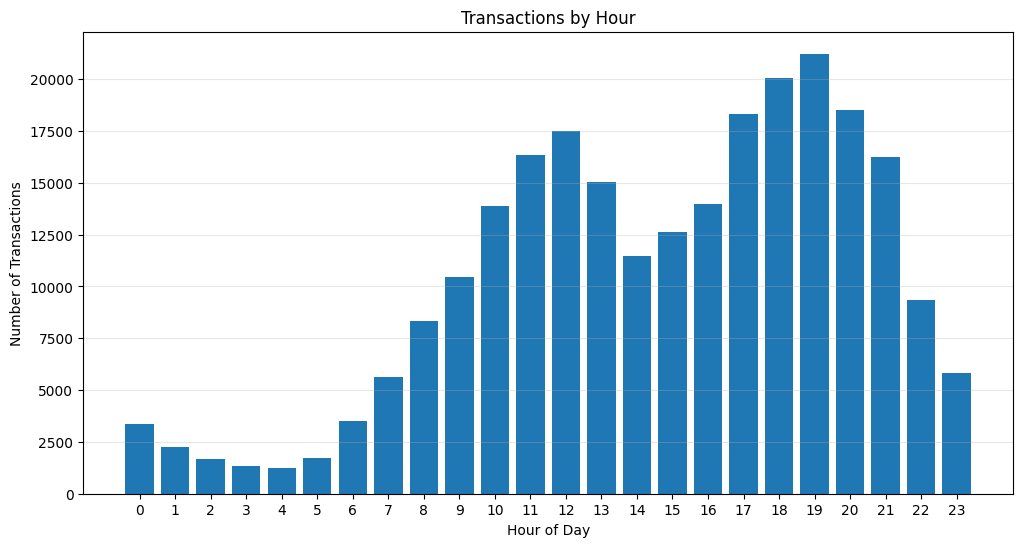

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(transaction_by_hour.index, transaction_by_hour.values)
plt.title("Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)

plt.show()

In [38]:
#Transactions by Weekday
transaction_by_weekday = df.groupby(df.index.day_name())["amount (INR)"].count()
transaction_by_weekday = transaction_by_weekday.reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])

In [39]:
#Transactions by Month
transaction_by_month = df.groupby(df.index.month_name())["amount (INR)"].count()

<BarContainer object of 7 artists>

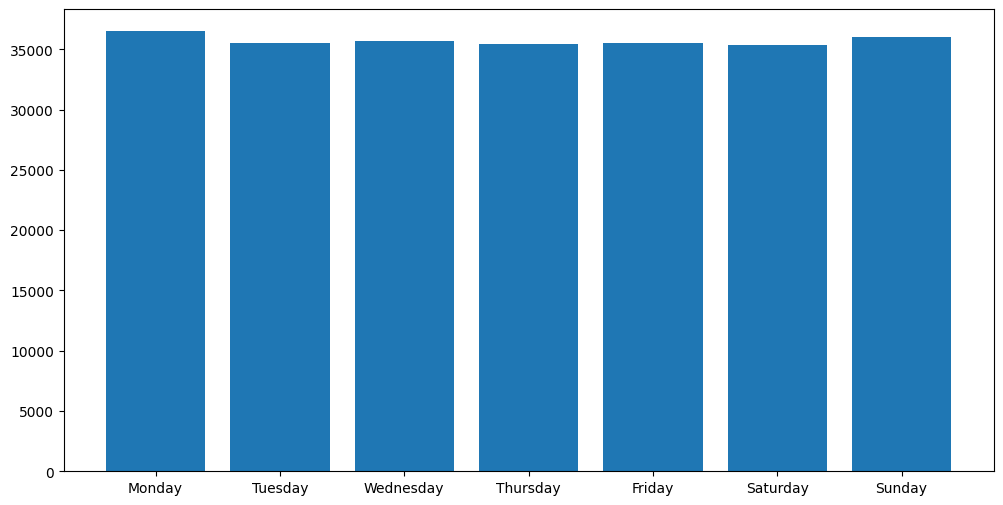

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.bar(transaction_by_weekday.index, transaction_by_weekday.values)